# Indian Stocks Sentiment Investment Strategy


Data sources used here:

- **Google News RSS**: free, no API key, good for company-level news sentiment.
- **Reddit via PRAW**: optional live social stream using free Reddit developer credentials.
- **Yahoo Finance via yfinance**: Indian stock prices using `.NS` tickers.

Strategy idea:

1. Collect recent text mentions for Indian stocks.
2. Score each mention using VADER sentiment.
3. Build an engagement-weighted sentiment signal.
4. Rank stocks monthly.
5. Buy the top 5 stocks for the next month.
6. Compare the strategy with Nifty 500.

## 1. Install Dependencies

In [1]:
!pip install -q pandas numpy matplotlib yfinance vaderSentiment feedparser praw
# VADER Sentiment is a rule-based NLP tool that analyzes text and predicts whether the sentiment is positive, negative, or neutral
# “Rule-based” means the system follows predefined human-written rules and dictionaries instead of learning patterns from training data
# feedparser is a Python library used to read and parse RSS and Atom news feeds from websites into structured data
# PRAW is a Python library that lets you interact with the Reddit API to read posts, comments, subreddits and automate Reddit-related tasks
# RSS and Atom are web feed formats that websites use to automatically publish updates like news articles, blog posts, or videos so users and apps can receive new content without visiting the website manually


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and Stock Universe

In [2]:
import os
import time
import datetime as dt
from urllib.parse import quote_plus
# Used to encode text safely for URLs by replacing spaces with + and special characters with URL-encoded values

import feedparser
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import yfinance as yf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm.auto import tqdm

plt.style.use("ggplot")
analyzer = SentimentIntensityAnalyzer()

c:\Users\sanra\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load Nifty 500 list from NSE
url = "https://archives.nseindia.com/content/indices/ind_nifty500list.csv"
nifty500 = pd.read_csv(url)

# Remove placeholder/dummy NSE symbols that do not exist on Yahoo Finance
nifty500 = nifty500[~nifty500["Symbol"].astype(str).str.contains("DUMMY", case=False, na=False)]

# Fix symbols for Yahoo Finance.
# Some NSE symbols contain dots (.), but Yahoo Finance uses dashes (-) instead.
nifty500["YahooSymbol"] = nifty500["Symbol"].astype(str).str.replace(".", "-", regex=False) + ".NS"

# Build search keywords for news/reddit sentiment.
# Example: RELIANCE.NS -> Reliance Industries, Reliance Industries stock, RELIANCE stock
stock_universe = {}

# Iterate through each stock in the Nifty 500 dataframe
for _, row in nifty500.iterrows():

    # Extract Yahoo Finance ticker symbol
    yahoo_symbol = row["YahooSymbol"]

    # Extract NSE stock symbol and convert to string
    nse_symbol = str(row["Symbol"])

    # Extract company name and convert to string
    company_name = str(row["Company Name"])

    # Store stock information in the dictionary
    # Key   -> Yahoo Finance ticker
    # Value -> List of searchable keywords related to the stock
    stock_universe[yahoo_symbol] = [
        company_name,
        f"{company_name} stock",
        f"{nse_symbol} stock",
    ]

# Create a list of all ticker symbols
tickers = list(stock_universe.keys())

# Print total number of loaded stocks
print(f"Loaded {len(tickers)} stocks")

# Display first 5 rows of the dataframe
print(nifty500.head())

# Display first 5 items from the stock universe dictionary
list(stock_universe.items())[:5]

Loaded 500 stocks
               Company Name                Industry     Symbol Series  \
0          360 ONE WAM Ltd.      Financial Services     360ONE     EQ   
1             3M India Ltd.             Diversified    3MINDIA     EQ   
2            ABB India Ltd.           Capital Goods        ABB     EQ   
3                  ACC Ltd.  Construction Materials        ACC     EQ   
4  ACME Solar Holdings Ltd.                   Power  ACMESOLAR     EQ   

      ISIN Code   YahooSymbol  
0  INE466L01038     360ONE.NS  
1  INE470A01017    3MINDIA.NS  
2  INE117A01022        ABB.NS  
3  INE012A01025        ACC.NS  
4  INE622W01025  ACMESOLAR.NS  


[('360ONE.NS', ['360 ONE WAM Ltd.', '360 ONE WAM Ltd. stock', '360ONE stock']),
 ('3MINDIA.NS', ['3M India Ltd.', '3M India Ltd. stock', '3MINDIA stock']),
 ('ABB.NS', ['ABB India Ltd.', 'ABB India Ltd. stock', 'ABB stock']),
 ('ACC.NS', ['ACC Ltd.', 'ACC Ltd. stock', 'ACC stock']),
 ('ACMESOLAR.NS',
  ['ACME Solar Holdings Ltd.',
   'ACME Solar Holdings Ltd. stock',
   'ACMESOLAR stock'])]

## 3. Collect Free News Sentiment Data

We query each company name and collect recent headlines.

Pipeline:

1. Fetch stock-related news from Google News RSS
2. Analyze headline sentiment using VADER Sentiment
3. Store everything in a pandas DataFrame

In [4]:
# Calculates the sentiment score of a news headline
def score_text(text):
    return analyzer.polarity_scores(str(text))["compound"]
# str(text) → ensures input is text
# polarity_scores() → returns sentiment metrics
# "compound" → overall sentiment score

# Downloads Google News articles for a stock-related search term
def fetch_google_news_for_query(query, max_items=25):
    # Create Search Query
    encoded_query = quote_plus(f'{query} India stock market')
    # Creates a Google News RSS search URL
    url = f'https://news.google.com/rss/search?q={encoded_query}&hl=en-IN&gl=IN&ceid=IN:en'
    # Uses feedparser to read the RSS XML feed
    feed = feedparser.parse(url)

    rows = []

    # Loops through latest news articles
    for entry in feed.entries[:max_items]:

        # Extract Publication Date
        published = getattr(entry, "published", None)

        # Converts text date into proper datetime format
        # errors="coerce" means invalid dates become NaT
        published_dt = pd.to_datetime(published, errors="coerce", utc=True)

        # Store News Row
        # Each article becomes a dictionary
        rows.append({
            "date": published_dt,
            "text": getattr(entry, "title", ""),
            "source": "google_news_rss",
            "url": getattr(entry, "link", None),
        })

    return rows


def collect_google_news_sentiment(stock_universe, max_items_per_query=25, sleep_seconds=0.25):
    # Stores all news articles from all stocks
    all_rows = []

    # Count Total Stocks
    total_symbols = len(stock_universe)

    # Loop Through Each Stock
    for i, (symbol, queries) in enumerate(stock_universe.items(), start=1):

        # It prints: first stock, every 25th stock, last stock
        if i == 1 or i % 25 == 0 or i == total_symbols:
            print(f"Collecting news for {i}/{total_symbols}: {symbol}")

        # Loop Through Search Queries
        for query in queries:

            # Fetch Google News Articles
            rows = fetch_google_news_for_query(query, max_items=max_items_per_query)

            # Add Extra Information
            for row in rows:
                row["symbol"] = symbol
                row["query"] = query
                row["sentiment_score"] = score_text(row["text"]) # Calculate Sentiment Score
            
            # Store All Articles
            all_rows.extend(rows)

            # Delay Between Requests
            time.sleep(sleep_seconds)

    # Convert to DataFrame
    df = pd.DataFrame(all_rows)

    # Prevents errors if no news was collected
    if df.empty:
        return df

    # Remove Invalid Dates
    df = df.dropna(subset=["date"])

    # Remove Timezone
    df["date"] = df["date"].dt.tz_convert(None)

    # Remove Duplicate News
    df = df.drop_duplicates(subset=["symbol", "text", "url"])

    # Sort by Date
    return df.sort_values("date")


# Start with a smaller sample so the notebook runs quickly.
# Set this to None if you want to collect news for the full Nifty 500
MAX_SYMBOLS_FOR_NEWS = None

if MAX_SYMBOLS_FOR_NEWS is None:
    news_universe = stock_universe
else:
    news_universe = dict(list(stock_universe.items())[:MAX_SYMBOLS_FOR_NEWS])

# Run Complete Pipeline
news_df = collect_google_news_sentiment(news_universe, max_items_per_query=25)
news_df.head()


,date,text,source,url,symbol,query,sentiment_score
13306,2013-12-16 08:00:00,GSK initiates voluntary open offer to increase...,google_news_rss,https://news.google.com/rss/articles/CBMi2wFBV...,GLAXO.NS,GLAXO stock,0.3182
18845,2014-07-24 07:00:00,Ipca Lab shares fall after company suspends US...,google_news_rss,https://news.google.com/rss/articles/CBMitgFBV...,IPCALAB.NS,IPCALAB stock,0.2960
944,2015-10-01 07:00:00,"Abbot India buys office space at BKC for Rs 1,...",google_news_rss,https://news.google.com/rss/articles/CBMiyAFBV...,ABBOTINDIA.NS,ABBOTINDIA stock,0.0000
12502,2017-01-08 09:45:06,Force Motors Share Price Today | NSE: FORC - I...,google_news_rss,https://news.google.com/rss/articles/CBMiXkFVX...,FORCEMOT.NS,FORCEMOT stock,0.2960
8196,2017-01-11 21:55:21,CBI Share Price Today | NSE: CBI - Investing.c...,google_news_rss,https://news.google.com/rss/articles/CBMiZkFVX...,CENTRALBK.NS,CENTRALBK stock,0.2960


## 4. Collect Live Reddit Data

Create a free Reddit app, then set these environment variables before running:

- `REDDIT_CLIENT_ID`
- `REDDIT_CLIENT_SECRET`
- `REDDIT_USER_AGENT`

Useful subreddits: `IndianStockMarket`, `IndiaInvestments`, `IndianStreetBets`.

This is a live stream, so stop the cell manually when you have enough posts.

In [5]:
# Optional live Reddit collector.
# This cell is safe to skip if you want the notebook to run only on Google News RSS.
def build_symbol_keyword_map(stock_universe):
    keyword_map = {}
    for symbol, names in stock_universe.items():
        base_symbol = symbol.replace(".NS", "")
        keyword_map[symbol] = [base_symbol.lower()] + [name.lower() for name in names]
    return keyword_map



def match_symbols(text, keyword_map):
    text_lower = str(text).lower()
    matched = []
    for symbol, keywords in keyword_map.items():
        if any(keyword in text_lower for keyword in keywords):
            matched.append(symbol)
    return matched


def collect_reddit_live(stock_universe, subreddits="IndianStockMarket+IndiaInvestments+IndianStreetBets", max_items=100):
    import praw

    client_id = os.getenv("REDDIT_CLIENT_ID")
    client_secret = os.getenv("REDDIT_CLIENT_SECRET")
    user_agent = os.getenv("REDDIT_USER_AGENT", "indian-stock-sentiment-project/0.1")

    if not client_id or not client_secret:
        raise ValueError("Set REDDIT_CLIENT_ID and REDDIT_CLIENT_SECRET before running this cell.")

    reddit = praw.Reddit(
        client_id=client_id,
        client_secret=client_secret,
        user_agent=user_agent,
    )

    keyword_map = build_symbol_keyword_map(stock_universe)
    rows = []

    for submission in reddit.subreddit(subreddits).stream.submissions(skip_existing=True):
        text = f"{submission.title}\n{submission.selftext}"
        symbols = match_symbols(text, keyword_map)

        for symbol in symbols:
            rows.append({
                "date": dt.datetime.utcfromtimestamp(submission.created_utc),
                "symbol": symbol,
                "text": text,
                "source": "reddit",
                "url": f"https://reddit.com{submission.permalink}",
                "likes": max(submission.score, 0),
                "comments": submission.num_comments,
                "sentiment_score": score_text(text),
            })

        if len(rows) >= max_items:
            break

    return pd.DataFrame(rows)


# Uncomment after setting Reddit credentials:
# reddit_df = collect_reddit_live(stock_universe, max_items=100)
# reddit_df.head()

## 5. Prepare Sentiment Data

Google News RSS does not provide likes, comments, views or retweets.

So we use the real headline sentiment first:

`sentiment_signal = sentiment_score`

Then, during monthly aggregation, we adjust by news volume:

`monthly_signal = avg_sentiment * log1p(news_count)`



In [6]:
# Use news only by default
# If you collected Reddit data, combine it like this:
# sentiment_raw_df = pd.concat([news_df, reddit_df], ignore_index=True)


sentiment_raw_df = news_df.copy()

# Converts the date column into pandas datetime format
sentiment_raw_df["date"] = pd.to_datetime(sentiment_raw_df["date"])

# Remove stale quote-page headlines and very old RSS items that are not useful trading signals.
junk_headline_pattern = "share price today|stock price today|quote|nse:|bse:"
recent_start = pd.Timestamp.today() - pd.DateOffset(years=5)
sentiment_raw_df = sentiment_raw_df[
    sentiment_raw_df["date"].between(recent_start, pd.Timestamp.today())
    & ~sentiment_raw_df["text"].astype(str).str.lower().str.contains(junk_headline_pattern, regex=True, na=False)
].copy()

# Google News RSS does not provide likes/comments
# Use the real headline sentiment here; monthly aggregation below adjusts by news volume
sentiment_raw_df["sentiment_signal"] = sentiment_raw_df["sentiment_score"]

# Create a Multi-Index
sentiment_df = sentiment_raw_df.set_index(["date", "symbol"]).sort_index()
sentiment_df.head()

,,text,source,url,query,sentiment_score,sentiment_signal
date,symbol,,,,,,
2021-07-09 07:00:00,TTML.NS,Rs 4 to Rs 47: This stock turned into a multib...,google_news_rss,https://news.google.com/rss/articles/CBMizgFBV...,Tata Teleservices (Maharashtra) Ltd. stock,0.000,0.000
2021-07-27 07:00:00,DIVISLAB.NS,"Your ₹20,000 would have become ₹1 crore in thi...",google_news_rss,https://news.google.com/rss/articles/CBMi3wFBV...,DIVISLAB stock,0.000,0.000
2021-08-13 07:00:00,FACT.NS,FACT to up the retirement age to 60 - The Time...,google_news_rss,https://news.google.com/rss/articles/CBMivAFBV...,FACT stock,0.000,0.000
2021-09-08 06:51:12,APARINDS.NS,Apar Industries (Nse) | Stock Share Price Live...,google_news_rss,https://news.google.com/rss/articles/CBMickFVX...,APARINDS stock,0.296,0.296
2021-09-08 07:41:40,USHAMART.NS,Usha Martin (Nse) | Stock Share Price Live - M...,google_news_rss,https://news.google.com/rss/articles/CBMickFVX...,USHAMART stock,0.296,0.296


## 6. Aggregate Monthly and Rank Stocks

In [7]:
# Aggregate daily news sentiment into monthly stock-level sentiment metrics
aggregated_df = (
    sentiment_df
    .reset_index("symbol")
    .groupby([pd.Grouper(freq="ME"), "symbol"]) # freq="ME" means: ME = Month End
    .agg(                                        # Calculate Monthly Statistics
        avg_sentiment=("sentiment_score", "mean"), # avg_sentiment = mean(sentiment_score)
        news_count=("sentiment_score", "size"), # news_count = number of headlines
        positive_share=("sentiment_score", lambda x: (x > 0.05).mean()), # Calculates the fraction of headlines with sentiment greater than 0.05
        negative_share=("sentiment_score", lambda x: (x < -0.05).mean()),
    )
)

# Require more than one headline so one random positive item cannot dominate the portfolio.
min_news_count = 2
aggregated_df = aggregated_df[aggregated_df["news_count"] >= min_news_count].copy()

# Final signal: sentiment strength, adjusted by coverage and penalized for negative headline share.
aggregated_df["sentiment_signal"] = (
    aggregated_df["avg_sentiment"]
    * np.log1p(aggregated_df["news_count"])
    * (1 + aggregated_df["positive_share"] - aggregated_df["negative_share"])
)

# Rank Stocks Within Each Month
# level=0 refers to: Month - So ranking happens separately for every month
aggregated_df["rank"] = (
    aggregated_df
    .groupby(level=0)["sentiment_signal"]
    .transform(lambda x: x.rank(ascending=False, method="first"))
)
# method="first" - If two stocks tie: The stock appearing first gets the better rank.

aggregated_df.sort_values(["date", "rank"]).head(20)

avg_sentiment  news_count  positive_share  \
date       symbol                                                     
2021-12-31 TEGA.NS             0.472300           2        1.000000   
2022-11-30 RHIM.NS             0.158000           2        0.500000   
2023-02-28 NSLNISP.NS          0.048967           3        0.666667   
2023-06-30 IPCALAB.NS          0.000000           2        0.000000   
2023-07-31 AARTIIND.NS         0.000000           4        0.000000   
           BAJFINANCE.NS       0.000000           2        0.000000   
           BALRAMCHIN.NS       0.000000           2        0.000000   
           CANFINHOME.NS       0.000000           2        0.000000   
           CENTRALBK.NS        0.000000           4        0.000000   
           ENGINERSIN.NS       0.000000           4        0.000000   
           GODREJIND.NS        0.000000           3        0.000000   
           LICHSGFIN.NS        0.000000           2        0.000000   
           NATCOPHARM.NS       0.000000           2        0.000000   
           NAVINFLUOR.NS       0.000000           2        0.000000   
           OBEROIRLTY.NS       0.000000           2        0.000000   
           PIDILITIND.NS       0.000000           2        0.000000   
           RKFORGE.NS          0.000000           2        0.000000   
2023-10-31 ARE&M.NS            0.273200           3        1.000000   
           ADANIENT.NS         0.271150           2        0.500000   
           BERGEPAINT.NS       0.000000           2        0.000000   

                          negative_share  sentiment_signal  rank  
date       symbol                                                 
2021-12-31 TEGA.NS              0.000000          1.037749   1.0  
2022-11-30 RHIM.NS              0.500000          0.173581   1.0  
2023-02-28 NSLNISP.NS           0.333333          0.090510   1.0  
2023-06-30 IPCALAB.NS           0.000000          0.000000   1.0  
2023-07-31 AARTIIND.NS          0.000000          0.000000   1.0  
           BAJFINANCE.NS        0.000000          0.000000   2.0  
           BALRAMCHIN.NS        0.000000          0.000000   3.0  
           CANFINHOME.NS        0.000000          0.000000   4.0  
           CENTRALBK.NS         0.000000          0.000000   5.0  
           ENGINERSIN.NS        0.000000          0.000000   6.0  
           GODREJIND.NS         0.000000          0.000000   7.0  
           LICHSGFIN.NS         0.000000          0.000000   8.0  
           NATCOPHARM.NS        0.000000          0.000000   9.0  
           NAVINFLUOR.NS        0.000000          0.000000  10.0  
           OBEROIRLTY.NS        0.000000          0.000000  11.0  
           PIDILITIND.NS        0.000000          0.000000  12.0  
           RKFORGE.NS           0.000000          0.000000  13.0  
2023-10-31 ARE&M.NS             0.000000          0.757471   1.0  
           ADANIENT.NS          0.000000          0.446833   2.0  
           BERGEPAINT.NS        0.000000          0.000000   3.0

## 7. Select Top Stocks for Next Month

In [8]:
candidate_n = 25
portfolio_n = 10

# Keep a wider candidate list. Momentum/liquidity filters later choose the final portfolio
filtered_df = aggregated_df[aggregated_df["rank"] <= candidate_n].copy()

# Move the symbol index level into a normal column
filtered_df = filtered_df.reset_index(level=1)

# Shift each date forward by 1 day, assuming the portfolio is rebalanced at the start of the next month
filtered_df.index = filtered_df.index + pd.DateOffset(days=1)

# Rebuild the MultiIndex using date and symbol
filtered_df = filtered_df.reset_index().set_index(["date", "symbol"])

# an empty dictionary to store portfolio holdings by date
fixed_dates = {}

# For each rebalance date:
# Get all selected stock symbols.
# Store them in a dictionary with the date as the key
for d in filtered_df.index.get_level_values("date").unique():
    fixed_dates[d.strftime("%Y-%m-%d")] = filtered_df.xs(d, level=0).index.tolist()


fixed_dates

{'2022-01-01': ['TEGA.NS'],
 '2022-12-01': ['RHIM.NS'],
 '2023-03-01': ['NSLNISP.NS'],
 '2023-07-01': ['IPCALAB.NS'],
 '2023-08-01': ['AARTIIND.NS',
  'BAJFINANCE.NS',
  'BALRAMCHIN.NS',
  'CANFINHOME.NS',
  'CENTRALBK.NS',
  'ENGINERSIN.NS',
  'GODREJIND.NS',
  'LICHSGFIN.NS',
  'NATCOPHARM.NS',
  'NAVINFLUOR.NS',
  'OBEROIRLTY.NS',
  'PIDILITIND.NS',
  'RKFORGE.NS'],
 '2023-11-01': ['ADANIENT.NS',
  'ARE&M.NS',
  'BERGEPAINT.NS',
  'CAPLIPOINT.NS',
  'CASTROLIND.NS',
  'FINCABLES.NS',
  'NESTLEIND.NS',
  'TATACHEM.NS',
  'TATACOMM.NS',
  'TORNTPOWER.NS'],
 '2023-12-01': ['GICRE.NS', 'MEDANTA.NS'],
 '2024-02-01': ['BANDHANBNK.NS', 'CGCL.NS'],
 '2024-03-01': ['NEULANDLAB.NS', 'ZEEL.NS'],
 '2024-04-01': ['KAJARIACER.NS', 'PCBL.NS', 'TATACHEM.NS', 'WELCORP.NS'],
 '2024-05-01': ['INDGN.NS', 'RKFORGE.NS'],
 '2024-06-01': ['CGCL.NS', 'CONCORDBIO.NS', 'DATAPATTNS.NS', 'INDGN.NS'],
 '2024-07-01': ['ARE&M.NS', 'INDIACEM.NS', 'JUBLINGREA.NS', 'TBOTEK.NS'],
 '2024-08-01': ['ABDL.NS',
  'AEGISLOG

## 8. Download Indian Stock Prices

In [ ]:
# Download historical stock price data covering the portfolio formation and holding periods
# Determine the required date range and download historical stock prices for all portfolio stock

# Use the earliest rebalance date and fetch an extra month of history for indicators
if fixed_dates:
    # Set the start date one month before the first rebalance date
    start_date = min(pd.to_datetime(list(fixed_dates.keys()))) - pd.DateOffset(months=1)
else:
    # Use the last two years if no rebalance dates are available
    start_date = pd.Timestamp.today() - pd.DateOffset(years=2)

# Set the end date to tomorrow to ensure the latest market data is included
end_date = pd.Timestamp.today() + pd.DateOffset(days=1)

# Download historical OHLCV data for all selected stocks from Yahoo Finance
prices_df = yf.download(
    tickers=tickers,
    start=start_date.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
    auto_adjust=True, # Adjust prices for stock splits and dividends automatically
    progress=False, # Disable progress bar
)

prices_df.tail()

$CCL.NS: possibly delisted; no price data found  (1d 2021-12-01 -> 2026-06-08)
$AJANTPHARM.NS: possibly delisted; no price data found  (1d 2021-12-01 -> 2026-06-08)
$TECHM.NS: possibly delisted; no price data found  (1d 2021-12-01 -> 2026-06-08)
$NCC.NS: possibly delisted; no price data found  (1d 2021-12-01 -> 2026-06-08)
$PERSISTENT.NS: possibly delisted; no price data found  (1d 2021-12-01 -> 2026-06-08)
$TEGA.NS: possibly delisted; no price data found  (1d 2021-12-01 -> 2026-06-08)
$DEEPAKNTR.NS: possibly delisted; no price data found  (1d 2021-12-01 -> 2026-06-08)
$TRITURBINE.NS: possibly delisted; no price data found  (1d 2021-12-01 -> 2026-06-08)
$BEML.NS: possibly delisted; no price data found  (1d 2021-12-01 -> 2026-06-08)
$MANKIND.NS: possibly delisted; no price data found  (1d 2021-12-01 -> 2026-06-08)
$OBEROIRLTY.NS: possibly delisted; no price data found  (1d 2021-12-01 -> 2026-06-08)
$GVT&D.NS: possibly delisted; no price data found  (1d 2021-12-01 -> 2026-06-08)

12 Fail

Price          Adj Close                                                  \
Ticker     AJANTPHARM.NS BEML.NS CCL.NS DEEPAKNTR.NS GVT&D.NS MANKIND.NS   
2026-06-01           NaN     NaN    NaN          NaN      NaN        NaN   
2026-06-02           NaN     NaN    NaN          NaN      NaN        NaN   
2026-06-03           NaN     NaN    NaN          NaN      NaN        NaN   
2026-06-04           NaN     NaN    NaN          NaN      NaN        NaN   
2026-06-05           NaN     NaN    NaN          NaN      NaN        NaN   

Price                                                   ...       Volume  \
Ticker     NCC.NS OBEROIRLTY.NS PERSISTENT.NS TECHM.NS  ... WHIRLPOOL.NS   
2026-06-01    NaN           NaN           NaN      NaN  ...       539613   
2026-06-02    NaN           NaN           NaN      NaN  ...       171356   
2026-06-03    NaN           NaN           NaN      NaN  ...        91944   
2026-06-04    NaN           NaN           NaN      NaN  ...       247674   
2026-06-05    NaN           NaN           NaN      NaN  ...       114633   

Price                                                                   \
Ticker      WIPRO.NS WOCKPHARMA.NS YESBANK.NS    ZEEL.NS ZENSARTECH.NS   
2026-06-01  26491139      11806406  141975429   92286105        758138   
2026-06-02  42476874       6165675  165063885   29387604       4509402   
2026-06-03  62282204       7368265  111470651   21003654        562118   
2026-06-04  40659957       3856902   77191326   80466080       1867657   
2026-06-05  43539069       3362470  148106091  230280587        457553   

Price                                                        
Ticker     ZENTEC.NS ZFCVINDIA.NS ZYDUSLIFE.NS ZYDUSWELL.NS  
2026-06-01    397315         6864      2045714       236247  
2026-06-02    396944        13907      1928305       303991  
2026-06-03    613409         7822      1403453       186246  
2026-06-04   5928324        10220      1016000       151209  
2026-06-05   1598541         9267       919205       245293  

[5 rows x 2512 columns]

## 9. Calculate Monthly Rebalanced Portfolio Returns

In [ ]:
# Build a monthly rebalanced equal-weight portfolio using sentiment-selected stocks, filtered by momentum and liquidity
# Create a sentiment-driven portfolio, filter stocks by momentum and liquidity and compute equal-weight monthly returns.

# Extract closing prices and ensure the data is in DataFrame format
close_prices = prices_df["Close"].copy()
if isinstance(close_prices, pd.Series):
    close_prices = close_prices.to_frame(tickers[0])

# Remove stocks with no price history and calculate daily log returns
close_prices = close_prices.dropna(axis=1, how="all")
returns_df = np.log(close_prices).diff().dropna()

# Extract trading volume data and align it with available price data
if "Volume" in prices_df.columns.get_level_values(0):
    volume_data = prices_df["Volume"].copy()
    if isinstance(volume_data, pd.Series):
        volume_data = volume_data.to_frame(tickers[0])
    volume_data = volume_data.reindex(columns=close_prices.columns)
# Create an empty volume DataFrame if volume data is unavailable
else:
    volume_data = pd.DataFrame(index=close_prices.index, columns=close_prices.columns)

# Filter selected stocks using momentum and liquidity criteria before portfolio construction
def filter_symbols_for_quality(rebalance_date, symbols, final_count):
    rebalance_ts = pd.to_datetime(rebalance_date)

    # Get historical data available before the rebalance date
    history_dates = close_prices.index[close_prices.index < rebalance_ts]

    # Keep only stocks that have return data available
    available = [symbol for symbol in symbols if symbol in returns_df.columns]

    # Exit early if no valid stocks or historical data exist
    if not available or len(history_dates) == 0:
        return available[:final_count]
    
    # Use the latest available trading day before rebalancing
    asof_date = history_dates[-1]

    # Rank stocks by 3-month momentum and keep only positive momentum names
    momentum = close_prices[available].pct_change(63).loc[asof_date].dropna()
    if not momentum.empty:
        positive_momentum = momentum[momentum > 0].sort_values(ascending=False)
        if not positive_momentum.empty:
            available = positive_momentum.index.tolist()

    # Prioritize liquid stocks using average 20-day dollar trading volume
    dollar_volume = (close_prices[available] * volume_data[available]).rolling(20).mean().loc[asof_date].dropna()
    if not dollar_volume.empty:
        available = dollar_volume.sort_values(ascending=False).head(max(final_count * 2, final_count)).index.tolist()

    # Return the final set of stocks for portfolio inclusion
    return available[:final_count]

# Initialize an empty DataFrame to store portfolio returns
portfolio_df = pd.DataFrame()

# Rebalance the portfolio at each predefined rebalance date
for rebalance_date, selected_symbols in fixed_dates.items():
    # Determine the month-end date for the holding period
    month_end = (pd.to_datetime(rebalance_date) + pd.offsets.MonthEnd()).strftime("%Y-%m-%d")

    # Apply quality filters to the sentiment-selected stocks
    available_symbols = filter_symbols_for_quality(rebalance_date, selected_symbols, portfolio_n)

    # Skip periods where no stocks pass the filters
    if not available_symbols:
        continue

    # Calculate equal-weight daily portfolio returns for the selected stocks
    monthly_returns = (
        returns_df.loc[rebalance_date:month_end, available_symbols]
        .mean(axis=1)
        .to_frame("portfolio_return")
    )

    # Append monthly portfolio returns to the overall portfolio history
    portfolio_df = pd.concat([portfolio_df, monthly_returns])

# Remove duplicate dates created during portfolio concatenation
portfolio_df = portfolio_df[~portfolio_df.index.duplicated(keep="first")]

# Display the first few portfolio return observations
portfolio_df.head()

,portfolio_return
2025-12-22,0.008530
2025-12-23,0.002209
2025-12-24,-0.001410
2025-12-26,0.001471
2025-12-29,-0.011132


## 10. Compare Against Nifty 500

In [ ]:
# Compare portfolio against multiple benchmarks

if portfolio_df.empty:
    # Print a message if no portfolio data exists
    print("portfolio_df is empty before benchmark merge.")
else:
    # Get the start date of the portfolio returns
    benchmark_start = portfolio_df.index.min().strftime("%Y-%m-%d")

    # Get the end date and add one extra day to include the last trading day
    benchmark_end = (
        portfolio_df.index.max() + pd.Timedelta(days=1)
    ).strftime("%Y-%m-%d")

    # Define benchmark indices to compare against
    benchmarks = {
        "nifty50_return": "^NSEI",     # Nifty 50
        "nifty500_return": "^CRSLDX",  # Nifty 500
    }

    # Loop through each benchmark index
    for return_col, ticker in benchmarks.items():
        # Download benchmark price data from Yahoo Finance
        benchmark_df = yf.download(
            tickers=ticker,
            start=benchmark_start,
            end=benchmark_end,
            auto_adjust=True,
            progress=False,
        )

        # Skip benchmark if data download fails
        if benchmark_df.empty:
            print(f"Could not download {ticker}")
            continue

        # Extract closing prices from benchmark data
        benchmark_close = benchmark_df["Close"]

        # Handle cases where Close prices are returned as a DataFrame
        if isinstance(benchmark_close, pd.DataFrame):

            # Select the first column containing closing prices
            benchmark_close = benchmark_close.iloc[:, 0]

        # Calculate daily log returns for the benchmark
        benchmark_ret = (
            np.log(benchmark_close)
            .diff()
            .to_frame(return_col)
        )

        # Merge benchmark returns with portfolio returns using dates
        portfolio_df = portfolio_df.merge(
            benchmark_ret,
            left_index=True,
            right_index=True,
            how="left",
        )
        
# Display the last few rows of the combined dataset
portfolio_df.tail()

,portfolio_return,nifty50_return,nifty500_return
2026-06-01,-0.002635,-0.007038,-0.009715
2026-06-02,0.012229,0.004308,0.003699
2026-06-03,-0.013043,-0.003325,-0.003080
2026-06-04,0.006075,0.000468,0.002040
2026-06-05,-0.006717,-0.002131,-0.001439


## 11. Plot Cumulative Returns

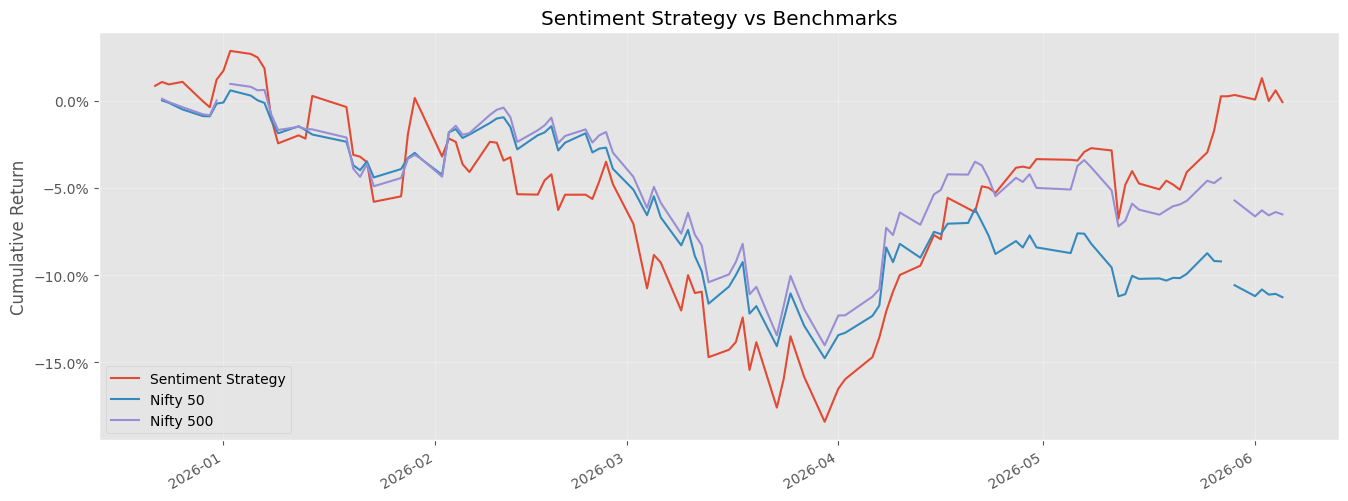

In [ ]:
# Checks whether portfolio_df contains any returns
if portfolio_df.empty:
    # If empty prevents plotting errors
    print("No portfolio returns available. Collect more sentiment history or use a wider date range.")
else:
    # Convert daily returns to cumulative returns
    cumulative_returns = np.exp(portfolio_df.cumsum()).sub(1)
    # Your dataframe contains log returns
    # First: portfolio_df.cumsum() - calculates cumulative log returns
    # Then: np.exp(...) - converts them back to normal returns
    # Finally: .sub(1) - gives cumulative percentage gain/loss

    # Rename columns for better labels
    cumulative_returns = cumulative_returns.rename(columns={
        "portfolio_return": "Sentiment Strategy",
        "nifty50_return": "Nifty 50",
        "nifty500_return": "Nifty 500",
    })

    # Create the plot
    ax = cumulative_returns.plot(figsize=(16, 6))

    ax.set_title("Sentiment Strategy vs Benchmarks")
    ax.set_ylabel("Cumulative Return")

    # Show percentages
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    ax.grid(True, alpha=0.3)

    plt.show()